# Classification ML Classique sur features N-Grammes

Ce notebook implémente et compare 4 algorithmes classiques de machine learning sur une représentation N-grammes des avis textuels Yelp :
- Logistic Regression
- Support Vector Machine (LinearSVC)
- Random Forest
- Naive Bayes (MultinomialNB)

**Objectif** : Prédire le sentiment (étoiles) à partir du texte de l'avis et sauvegarder le meilleur modèle.

In [1]:
# Importer les bibliothèques nécessaires
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et Préparation des données

In [2]:
# Définir les chemins
DATA_DIR = '../../data/cleaned'
MODELS_DIR = '../../models/'

# Créer le dossier models s'il n'existe pas
os.makedirs(MODELS_DIR, exist_ok=True)

# Charger les données pré-traitées
print("Chargement des données...")
try:
    df = pd.read_parquet(os.path.join(DATA_DIR, 'reviews_clean.parquet'), engine='fastparquet')
except Exception as e:
    df = pd.read_parquet(os.path.join(DATA_DIR, 'reviews_clean.parquet'))

# On s'assure qu'il n'y a pas de valeurs nulles dans le texte ou la cible
df = df.dropna(subset=['text', 'stars'])

print(f"Dimensions du dataset : {df.shape}")
print(f"Distribution de la cible (stars) :\n{df['stars'].value_counts(normalize=True).sort_index()}")

Chargement des données...
Dimensions du dataset : (999985, 9)
Distribution de la cible (stars) :
stars
1    0.153056
2    0.077629
3    0.098714
4    0.207953
5    0.462647
Name: proportion, dtype: float64


In [3]:
# Pour des raisons de performance sur la classification classique, 
# on échantillonne le dataset à 5000 exemples (sinon la mémoire/RAM locale risque de saturer)
df = df.sample(n=5000, random_state=42)

X = df['text']
y = df['stars']

### Split (Train / Val / Test -> 80% / 10% / 10%)

In [4]:
# Premier split : extraire 20% pour temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Deuxième split : diviser temp en val(50%) et test(50%), ce qui fait 10% de l'original chacun
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Taille Train : {X_train.shape[0]} \nTaille Val   : {X_val.shape[0]} \nTaille Test  : {X_test.shape[0]}")

Taille Train : 4000 
Taille Val   : 500 
Taille Test  : 500


## 2. Vectorisation (N-Grammes)
Nous allons vectoriser notre texte avec CountVectorizer(ngram_range=(1,2)) en ajustant uniquement sur l'ensemble d'entraînement pour éviter le data leakage.

In [5]:
print("Vectorisation N-Grammes en cours...")
# On limite à 10000 features pour que les modèles de base tournent de manière fluide.
vectorizer = CountVectorizer(max_features=10000, min_df=5, max_df=0.7, ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f"Forme de la matrice N-Grammes d'entraînement : {X_train_vec.shape}")

Vectorisation N-Grammes en cours...
Forme de la matrice N-Grammes d'entraînement : (4000, 10000)


## 3. Entraînement et Évaluation des Modèles

In [6]:
def evaluate_model(model, X_train, y_train, X_eval, y_eval):
    """Entraîne le modèle, fait des prédictions et renvoie les métriques."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_eval)
    
    # Metrics
    # macro avg is good to ensure we balance across all star ratings 
    # (especially minority classes if un-balanced)
    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average='macro')
    rec = recall_score(y_eval, y_pred, average='macro')
    f1 = f1_score(y_eval, y_pred, average='macro')
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}, y_pred

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matrice de confusion - {title}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.show()

In [7]:
# Initialisation des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    'Linear SVC': LinearSVC(random_state=42, dual=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Naive Bayes': MultinomialNB()
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n--- Entraînement de {name} ---")
    metrics, y_pred = evaluate_model(model, X_train_vec, y_train, X_val_vec, y_val)
    results[name] = metrics
    predictions[name] = y_pred
    
    print(f"Accuracy  : {metrics['accuracy']:.4f}")
    print(f"Modèle {name} prêt.")


--- Entraînement de Logistic Regression ---
Accuracy  : 0.6340
Modèle Logistic Regression prêt.

--- Entraînement de Linear SVC ---
Accuracy  : 0.6020
Modèle Linear SVC prêt.

--- Entraînement de Random Forest ---
Accuracy  : 0.5420
Modèle Random Forest prêt.

--- Entraînement de Naive Bayes ---
Accuracy  : 0.5960
Modèle Naive Bayes prêt.


## 4. Comparaison et Sélection du Meilleur Modèle

In [8]:
# Tableau comparatif
results_df = pd.DataFrame(results).T
print("\n=== TABLEAU COMPARATIF (sur Validation set) ===")
display(results_df.sort_values(by='f1', ascending=False))

# Identifier le meilleur
best_model_name = results_df['f1'].idxmax()
best_model = models[best_model_name]

print(f"\nMeilleur modèle sélectionné (basé sur F1 macro) : {best_model_name}")


=== TABLEAU COMPARATIF (sur Validation set) ===


,accuracy,precision,recall,f1
Logistic Regression,0.634,0.532930,0.514709,0.520764
Naive Bayes,0.596,0.503796,0.517821,0.508323
Linear SVC,0.602,0.490972,0.484012,0.485192
Random Forest,0.542,0.365202,0.320541,0.297583



Meilleur modèle sélectionné (basé sur F1 macro) : Logistic Regression


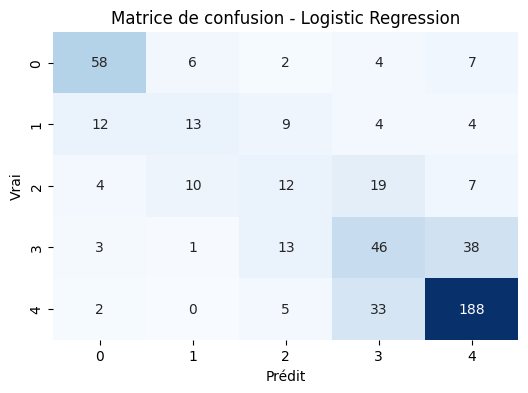


Rapport de classification détaillé :

              precision    recall  f1-score   support

           1       0.73      0.75      0.74        77
           2       0.43      0.31      0.36        42
           3       0.29      0.23      0.26        52
           4       0.43      0.46      0.44       101
           5       0.77      0.82      0.80       228

    accuracy                           0.63       500
   macro avg       0.53      0.51      0.52       500
weighted avg       0.62      0.63      0.62       500



In [9]:
# Visualiser la matrice de confusion du meilleur modèle
plot_confusion(y_val, predictions[best_model_name], best_model_name)

# Rapport détaillé
print("\nRapport de classification détaillé :\n")
print(classification_report(y_val, predictions[best_model_name]))

## 5. Test Final et Sauvegarde

In [10]:
# Optionnel : Evaluer le meilleur modèle sur le test set pour avoir un résultat final non biaisé
test_pred = best_model.predict(X_test_vec)
test_f1 = f1_score(y_test, test_pred, average='macro')
print(f"Performance finale sur l'ensemble de TEST ({best_model_name}) - F1 Macro : {test_f1:.4f}")

Performance finale sur l'ensemble de TEST (Logistic Regression) - F1 Macro : 0.4590


In [11]:
model_path = os.path.join(MODELS_DIR, 'best_ngram_classifier.pkl')
vectorizer_path = os.path.join(MODELS_DIR, 'count_vectorizer.pkl')

# Sauvegarder le modèle
joblib.dump(best_model, model_path)
# Sauvegarder aussi le vectorizer pour la pipeline d'inférence (Epic 6)
joblib.dump(vectorizer, vectorizer_path)

print(f"Modèle sauvegardé : {model_path}")
print(f"Vectorizer sauvegardé : {vectorizer_path}")

Modèle sauvegardé : ../../models/best_ngram_classifier.pkl
Vectorizer sauvegardé : ../../models/count_vectorizer.pkl
